## 1. Loading Dataset

The dataset contains historical Barcelona Bicing station status observations from August 2018 to March 2019.

Only the columns required for this project are loaded to reduce memory usage.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, confusion_matrix)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
import folium

In [3]:
useful_columns = ['id', 'latitude', 'longitude', 'slots', 'bikes', 'status', 'updateTime']

ags = pd.read_csv("agosto2018.csv", usecols=useful_columns)
sep = pd.read_csv( "septiembre2018.csv", sep=';',  decimal=',',  usecols=useful_columns)
oct = pd.read_csv("octubre2018.csv", usecols=useful_columns)
nov = pd.read_csv("noviembre2018.csv", usecols=useful_columns)
dec = pd.read_csv("deciembre2018.csv", usecols=useful_columns)
jan = pd.read_csv("enero2019.csv", usecols=useful_columns)
feb = pd.read_csv("febrero2019.csv", usecols=useful_columns)
mar = pd.read_csv("marzo2019.csv", usecols=useful_columns)

df = pd.concat([ags, sep, oct, nov, dec, jan, feb, mar], ignore_index=True)

df['updateTime'] = pd.to_datetime(df['updateTime'], dayfirst=True,  errors='coerce')

print("Dataset shape:", df.shape)
print("Date range:", df['updateTime'].min(), "to", df['updateTime'].max())
print("Number of stations:", df['id'].nunique())

df.head()

C:\Users\Alumne_mati1\AppData\Local\Temp\ipykernel_9508\3490902001.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['updateTime'] = pd.to_datetime(df['updateTime'], dayfirst=True,  errors='coerce')


Dataset shape: (24424811, 7)
Date range: 2018-08-01 17:15:08 to 2019-03-31 23:54:12
Number of stations: 467


,id,latitude,longitude,slots,bikes,status,updateTime
0,1,41.397952,2.180042,2,25,OPN,2018-08-01 17:43:08
1,2,41.395530,2.177060,0,27,OPN,2018-08-01 17:43:08
2,3,41.394072,2.183441,19,7,OPN,2018-08-01 17:43:08
3,4,41.393470,2.181490,11,7,OPN,2018-08-01 17:43:08
4,5,41.391075,2.180223,34,2,OPN,2018-08-01 17:43:08


## 2. Data Quality and Cleaning

Before creating the target and features, the dataset was checked for duplicated observations, missing values, invalid timestamps, and impossible bike or slot values.

Duplicate station-timestamp observations were removed to avoid counting the same station status more than once.

In [4]:
print("Missing values:")
print(df.isna().sum())

print("\nInvalid timestamps:")
print(df['updateTime'].isna().sum())

print("\nNegative bike values:")
print((df['bikes'] < 0).sum())

print("\nNegative slot values:")
print((df['slots'] < 0).sum())

print("\nDuplicated station-timestamp observations:")
print(df.duplicated(subset=['id', 'updateTime']).sum())

Missing values:
id            0
latitude      0
longitude     0
slots         0
bikes         0
status        0
updateTime    0
dtype: int64

Invalid timestamps:
0

Negative bike values:
0

Negative slot values:
0

Duplicated station-timestamp observations:
25465


In [5]:
df = df.drop_duplicates( subset=['id', 'updateTime', 'bikes', 'slots', 'status']).copy()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (24399628, 7)


## 3. Operational Cleaning

For this project, the prediction task focuses on operational stations.

Observations where a station is open but both `bikes` and `slots` are equal to zero are treated as anomalous operational records and removed.

A temporary observed capacity variable is also created as the sum of available bikes and free slots.

In [6]:
df['capacity'] = df['bikes'] + df['slots']

anomalous_open_rows = df[(df['status'] == 'OPN') & (df['bikes'] == 0) & (df['slots'] == 0)]

print("Unnormal open rows with zero bikes and zero slots:")
print(len(anomalous_open_rows))

print("\nPercentage of open observations:")
print(len(anomalous_open_rows) / len(df[df['status'] == 'OPN']) * 100)

df = df[
    ~(
        (df['status'] == 'OPN') &
        (df['bikes'] == 0) &
        (df['slots'] == 0)
    )
].copy()

print("\nDataset shape after operational cleaning:")
print(df.shape)

Unnormal open rows with zero bikes and zero slots:
2784

Percentage of open observations:
0.015027785208902408

Dataset shape after operational cleaning:
(24396844, 8)


## 4. Defining Prediction Observations and Target

The prediction task focuses on stations that are currently open and have at least one available bike.

The target is binary:

- `1`: the same station reaches zero available bikes while still open at least once during the following 60 minutes.
- `0`: otherwise.

Actual timestamps are used to define the 60minute prediction window.

In [7]:
df = df.sort_values(['id', 'updateTime']).copy()

prediction_df = df[
    (df['status'] == 'OPN') &
    (df['bikes'] > 0)
][['id', 'updateTime','bikes','slots','capacity','latitude','longitude']].copy()

last_complete_time = df['updateTime'].max() - pd.Timedelta(minutes=60)

prediction_df = prediction_df[prediction_df['updateTime'] <= last_complete_time].copy()

empty_events = df[(df['status'] == 'OPN') & (df['bikes'] == 0)][['id', 'updateTime']].copy()

empty_events = empty_events.rename(columns={'updateTime': 'next_empty_time'})


prediction_df = prediction_df.sort_values(['updateTime', 'id'])
empty_events = empty_events.sort_values(['next_empty_time', 'id'])

prediction_df = pd.merge_asof(
    prediction_df,
    empty_events,
    left_on='updateTime',
    right_on='next_empty_time',
    by='id',
    direction='forward',
    allow_exact_matches=False
)


prediction_df['target'] = (
    prediction_df['next_empty_time']
    <= prediction_df['updateTime'] + pd.Timedelta(minutes=60)
).astype(int)


print("Prediction dataset shape:", prediction_df.shape)

print("\nTarget distribution:")
print(prediction_df['target'].value_counts())

print("\nTarget percentage:")
print(prediction_df['target'].value_counts(normalize=True) * 100)

Prediction dataset shape: (16426956, 9)

Target distribution:
target
0    15028463
1     1398493
Name: count, dtype: int64

Target percentage:
target
0    91.486597
1     8.513403
Name: proportion, dtype: float64


### Target Sanity Check

A small sample of positive observations is checked to verify that the next empty event occurs within the defined 60-minute prediction window.

In [8]:
positive_examples = prediction_df[ prediction_df['target'] == 1].copy()

positive_examples['minutes_until_empty'] = (
    positive_examples['next_empty_time'] -
    positive_examples['updateTime']
).dt.total_seconds() / 60

positive_examples[[
    'id',
    'updateTime',
    'bikes',
    'next_empty_time',
    'minutes_until_empty'
]].head(10)

,id,updateTime,bikes,next_empty_time,minutes_until_empty
9,12,2018-08-01 17:15:08,1,2018-08-01 18:00:19,45.183333
10,13,2018-08-01 17:15:08,7,2018-08-01 17:43:08,28.000000
15,18,2018-08-01 17:15:08,4,2018-08-01 18:15:08,60.000000
19,23,2018-08-01 17:15:08,2,2018-08-01 17:43:08,28.000000
23,27,2018-08-01 17:15:08,2,2018-08-01 17:43:08,28.000000
39,44,2018-08-01 17:15:08,5,2018-08-01 17:45:08,30.000000
41,46,2018-08-01 17:15:08,2,2018-08-01 17:43:08,28.000000
54,60,2018-08-01 17:15:08,3,2018-08-01 18:00:19,45.183333
61,67,2018-08-01 17:15:08,5,2018-08-01 18:00:19,45.183333
62,69,2018-08-01 17:15:08,1,2018-08-01 17:43:08,28.000000


In [9]:
prediction_df = prediction_df.drop(columns=['next_empty_time'])

## 5. Feature Engineering

The model uses current station status, recent historical availability, and simple time based features.

Time features are extracted from the observation timestamp. Recent bike availability from approximately 15 and 30 minutes earlier is also added using only past observations.

In [10]:
prediction_df['hour'] = prediction_df['updateTime'].dt.hour
prediction_df['day_of_week'] = prediction_df['updateTime'].dt.dayofweek
prediction_df['is_weekend'] = ( prediction_df['day_of_week'] >= 5).astype(int)

prediction_df['month'] = prediction_df['updateTime'].dt.month


prediction_df['occupancy_ratio'] = ( prediction_df['bikes'] / prediction_df['capacity'])

In [11]:
history_source = df[ ['id', 'updateTime', 'bikes']].copy()

history_source = history_source.sort_values( ['updateTime', 'id'])

prediction_df = prediction_df.sort_values( ['updateTime', 'id'])

prediction_df['time_15m_ago'] = ( prediction_df['updateTime'] - pd.Timedelta(minutes=15))

prediction_df = pd.merge_asof(
    prediction_df,
    history_source,
    left_on='time_15m_ago',
    right_on='updateTime',
    by='id',
    direction='backward',
    tolerance=pd.Timedelta(minutes=7),
    suffixes=('', '_15m')
)

prediction_df = prediction_df.rename( columns={'bikes_15m': 'bikes_15m_ago'})


prediction_df['time_30m_ago'] = (
    prediction_df['updateTime'] -
    pd.Timedelta(minutes=30)
)

prediction_df = pd.merge_asof(
    prediction_df,
    history_source,
    left_on='time_30m_ago',
    right_on='updateTime',
    by='id',
    direction='backward',
    tolerance=pd.Timedelta(minutes=7),
    suffixes=('', '_30m')
)

prediction_df = prediction_df.rename(
    columns={'bikes_30m': 'bikes_30m_ago'}
)

prediction_df['bike_change_15m'] = (
    prediction_df['bikes'] - prediction_df['bikes_15m_ago']
)

prediction_df['bike_change_30m'] = (
    prediction_df['bikes'] - prediction_df['bikes_30m_ago']
)

In [12]:
prediction_df = prediction_df.dropna(subset=[ 'bikes_15m_ago', 'bikes_30m_ago', 'bike_change_15m', 'bike_change_30m']).copy()

print(prediction_df.shape)

(14833380, 21)


## 6. Target Distribution and Chronological Split

Because the dataset is time-based, the data is split chronologically instead of randomly. Earlier observations are used for training, later observations for validation, and the most recent period for testing.This helps avoid leakage from future observations into the training process.

In [13]:
print("Target distribution after feature engineering:")
print(prediction_df['target'].value_counts(normalize=True) * 100)

print("\nDate range:")
print(prediction_df['updateTime'].min())
print(prediction_df['updateTime'].max())

Target distribution after feature engineering:
target
0    91.461629
1     8.538371
Name: proportion, dtype: float64

Date range:
2018-08-01 19:00:15
2019-03-30 16:34:12


In [14]:
train_df = prediction_df[ prediction_df['updateTime'] < '2019-01-01'].copy()

val_df = prediction_df[
    (prediction_df['updateTime'] >= '2019-01-01 01:00:00') &
    (prediction_df['updateTime'] < '2019-02-01')
].copy()

test_df = prediction_df[
    (prediction_df['updateTime'] >= '2019-02-01 01:00:00') &
    (prediction_df['updateTime'] < '2019-03-01')
].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain positive rate:", train_df['target'].mean() * 100)
print("Validation positive rate:", val_df['target'].mean() * 100)
print("Test positive rate:", test_df['target'].mean() * 100)

Train: (9521722, 21)
Validation: (2966095, 21)
Test: (1711745, 21)

Train positive rate: 9.004852273569844
Validation positive rate: 9.113733713856096
Test positive rate: 7.418277839280968


## 7. Model Features

The models use current station availability, recent historical bike changes, time based variables, and station location.

The raw timestamp and station ID are not used directly as model features.

In [15]:
model_features = [
    'bikes',
    'slots',
    'capacity',
    'occupancy_ratio',
    'bikes_15m_ago',
    'bikes_30m_ago',
    'bike_change_15m',
    'bike_change_30m',
    'hour',
    'day_of_week',
    'is_weekend',
    'month',
    'latitude',
    'longitude'
]

X_train = train_df[model_features]
X_val = val_df[model_features]
X_test = test_df[model_features]

y_train = train_df['target']
y_val = val_df['target']
y_test = test_df['target']

print(X_train.shape, X_val.shape, X_test.shape)

(9521722, 14) (2966095, 14) (1711745, 14)


## 8. Baseline Model

In [16]:
dummy_model = DummyClassifier(strategy='most_frequent')

dummy_model.fit(X_train, y_train)

dummy_predictions = dummy_model.predict(X_val)

print("Dummy Classifier Results")
print("------------------------")
print("Accuracy:", accuracy_score(y_val, dummy_predictions))
print("Precision:", precision_score(y_val, dummy_predictions, zero_division=0))
print("Recall:", recall_score(y_val, dummy_predictions))

Dummy Classifier Results
------------------------
Accuracy: 0.908862662861439
Precision: 0.0
Recall: 0.0


## 9. Rule-Based Baseline

A simple rule predicts that a station is at risk of becoming empty when it currently has two or fewer available bikes.

In [17]:
rule_predictions = (X_val['bikes'] <= 2).astype(int)

print("Rule-Based Baseline Results")
print("---------------------------")
print("Accuracy:", accuracy_score(y_val, rule_predictions))
print("Precision:", precision_score(y_val, rule_predictions, zero_division=0))
print("Recall:", recall_score(y_val, rule_predictions))

Rule-Based Baseline Results
---------------------------
Accuracy: 0.891650469725346
Precision: 0.43318597157985933
Recall: 0.6122328186385126


## 10. Logistic Regression

In [18]:
logistic_features = [
    'bikes',
    'occupancy_ratio',
    'bikes_15m_ago',
    'bikes_30m_ago',
    'bike_change_15m',
    'bike_change_30m',
    'hour',
    'day_of_week',
    'is_weekend',
    'month',
    'latitude',
    'longitude'
]

X_train_log = train_df[logistic_features]
X_val_log = val_df[logistic_features]

logistic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

logistic_pipeline.fit(X_train_log, y_train)

logistic_predictions = logistic_pipeline.predict(X_val_log)
logistic_probabilities = logistic_pipeline.predict_proba(X_val_log)[:, 1]

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy:", accuracy_score(y_val, logistic_predictions))
print("Precision:", precision_score(y_val, logistic_predictions, zero_division=0))
print("Recall:", recall_score(y_val, logistic_predictions))

Logistic Regression Results
---------------------------
Accuracy: 0.9168256579779137
Precision: 0.6130539254635791
Recall: 0.23689895753952694


## 11. Decision Tree

In [19]:
tree_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=100,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_val)

print("Decision Tree Results")
print("---------------------")
print("Accuracy:", accuracy_score(y_val, tree_predictions))
print("Precision:", precision_score(y_val, tree_predictions, zero_division=0))
print("Recall:", recall_score(y_val, tree_predictions))

Decision Tree Results
---------------------
Accuracy: 0.9291290400341189
Precision: 0.6642565935447202
Recall: 0.44963783931755463


### Hyperparameter Tuning for the Decision Tree

In [20]:
tree_depths = [5, 8, 12]

for depth in tree_depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_val)

    print(f"Max depth = {depth}")
    print("Accuracy:", accuracy_score(y_val, predictions))
    print("Precision:", precision_score(y_val, predictions, zero_division=0))
    print("Recall:", recall_score(y_val, predictions))
    print("-" * 30)

Max depth = 5
Accuracy: 0.9265434856267247
Precision: 0.6524390598385006
Recall: 0.4151641375840664
------------------------------
Max depth = 8
Accuracy: 0.9291290400341189
Precision: 0.6642565935447202
Recall: 0.44963783931755463
------------------------------
Max depth = 12
Accuracy: 0.9316717772020114
Precision: 0.6749593983717971
Recall: 0.4827502016114116
------------------------------


In [21]:
best_tree_model = DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=100,
    random_state=42
)

best_tree_model.fit(X_train, y_train)

best_tree_predictions = best_tree_model.predict(X_val)

## 12. Random Forest

In [22]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_val)

print("Random Forest Results")
print("---------------------")
print("Accuracy:", accuracy_score(y_val, random_forest_predictions))
print("Precision:", precision_score(y_val, random_forest_predictions, zero_division=0))
print("Recall:", recall_score(y_val, random_forest_predictions))

Random Forest Results
---------------------
Accuracy: 0.9322398641985506
Precision: 0.6960756035901525
Recall: 0.4553014553014553


### Hyperparameter Tuning for Random Forest

In [23]:
rf_configs = [
    {'n_estimators': 50, 'max_depth': 8},
    {'n_estimators': 100, 'max_depth': 12},
    {'n_estimators': 150, 'max_depth': 12}
]

rf_results = []

for config in rf_configs:

    model = RandomForestClassifier(
        n_estimators=config['n_estimators'],
        max_depth=config['max_depth'],
        min_samples_leaf=100,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_val)

    rf_results.append({
        'n_estimators': config['n_estimators'],
        'max_depth': config['max_depth'],
        'Accuracy': accuracy_score(y_val, predictions),
        'Precision': precision_score(y_val, predictions, zero_division=0),
        'Recall': recall_score(y_val, predictions)
    })

rf_results = pd.DataFrame(rf_results)

rf_results

,n_estimators,max_depth,Accuracy,Precision,Recall
0,50,8,0.929517,0.686125,0.417713
1,100,12,0.932240,0.696076,0.455301
2,150,12,0.932218,0.696324,0.454454


In [24]:
best_random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=100,
    random_state=42,
    n_jobs=-1
)

best_random_forest_model.fit(X_train, y_train)

best_random_forest_predictions = best_random_forest_model.predict(X_val)

## 13. Neural Network

In [25]:
neural_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(
        hidden_layer_sizes=(32,),
        max_iter=50,
        random_state=42
    ))
])

neural_pipeline.fit(X_train_log, y_train)

neural_predictions = neural_pipeline.predict(X_val_log)

print("Neural Network Results")
print("----------------------")
print("Accuracy:", accuracy_score(y_val, neural_predictions))
print("Precision:", precision_score(y_val, neural_predictions, zero_division=0))
print("Recall:", recall_score(y_val, neural_predictions))

Neural Network Results
----------------------
Accuracy: 0.9095184071986905
Precision: 0.7679801598236429
Recall: 0.010309926680033442


### Neural Network Tuning


In [26]:
hidden_sizes = [(16,), (32,), (64,)]

for hidden_size in hidden_sizes:

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(
            hidden_layer_sizes=hidden_size,
            max_iter=50,
            random_state=42
        ))
    ])

    model.fit(X_train_log, y_train)

    predictions = model.predict(X_val_log)

    print(f"Hidden layer size = {hidden_size}")
    print("Accuracy:", accuracy_score(y_val, predictions))
    print("Precision:", precision_score(y_val, predictions, zero_division=0))
    print("Recall:", recall_score(y_val, predictions))
    print("-" * 30)

Hidden layer size = (16,)
Accuracy: 0.9265087598340579
Precision: 0.683902068810434
Recall: 0.36002249169508954
------------------------------
Hidden layer size = (32,)
Accuracy: 0.9095184071986905
Precision: 0.7679801598236429
Recall: 0.010309926680033442
------------------------------
Hidden layer size = (64,)
Accuracy: 0.9092692580648968
Precision: 0.8667883211678832
Recall: 0.005271491036615592
------------------------------


### Final Neural Network

In [38]:
final_neural_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(
        hidden_layer_sizes=(16,),
        max_iter=100,
        random_state=42
    ))
])

final_neural_pipeline.fit(X_train_log, y_train)

final_neural_predictions = final_neural_pipeline.predict(X_val_log)

print("Final Neural Network Results")
print("----------------------------")
print("Accuracy:", accuracy_score(y_val, final_neural_predictions))
print("Precision:", precision_score(y_val, final_neural_predictions, zero_division=0))
print("Recall:", recall_score(y_val, final_neural_predictions))

Final Neural Network Results
----------------------------
Accuracy: 0.9265087598340579
Precision: 0.683902068810434
Recall: 0.36002249169508954


## 14. Model Comparison

The validation performance of all models is compared using accuracy, precision, and recall.

In [39]:
results = pd.DataFrame({
    'Model': [
        'Dummy Classifier',
        'Rule-Based Baseline',
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Neural Network'
    ],
    'Accuracy': [
        accuracy_score(y_val, dummy_predictions),
        accuracy_score(y_val, rule_predictions),
        accuracy_score(y_val, logistic_predictions),
        accuracy_score(y_val, best_tree_predictions),
        accuracy_score(y_val, best_random_forest_predictions),
        accuracy_score(y_val, final_neural_predictions)
    ],
    'Precision': [
        precision_score(y_val, dummy_predictions, zero_division=0),
        precision_score(y_val, rule_predictions, zero_division=0),
        precision_score(y_val, logistic_predictions, zero_division=0),
        precision_score(y_val, best_tree_predictions, zero_division=0),
        precision_score(y_val, best_random_forest_predictions, zero_division=0),
        precision_score(y_val, final_neural_predictions, zero_division=0)
    ],
    'Recall': [
        recall_score(y_val, dummy_predictions),
        recall_score(y_val, rule_predictions),
        recall_score(y_val, logistic_predictions),
        recall_score(y_val, best_tree_predictions),
        recall_score(y_val, best_random_forest_predictions),
        recall_score(y_val, final_neural_predictions)
    ]
})

results

,Model,Accuracy,Precision,Recall
0,Dummy Classifier,0.908863,0.000000,0.000000
1,Rule-Based Baseline,0.891650,0.433186,0.612233
2,Logistic Regression,0.916826,0.613054,0.236899
3,Decision Tree,0.931672,0.674959,0.482750
4,Random Forest,0.932240,0.696076,0.455301
5,Neural Network,0.926509,0.683902,0.360022


## 15. Final Test Evaluation

In [40]:
final_test_predictions = best_tree_model.predict(X_test)

print("Final Decision Tree Test Results")
print("--------------------------------")
print("Accuracy:", accuracy_score(y_test, final_test_predictions))
print("Precision:", precision_score(y_test, final_test_predictions, zero_division=0))
print("Recall:", recall_score(y_test, final_test_predictions))

Final Decision Tree Test Results
--------------------------------
Accuracy: 0.9405378721713806
Precision: 0.6366456259083317
Recall: 0.4622702430265707


## 16. Final Test Confusion Matrix

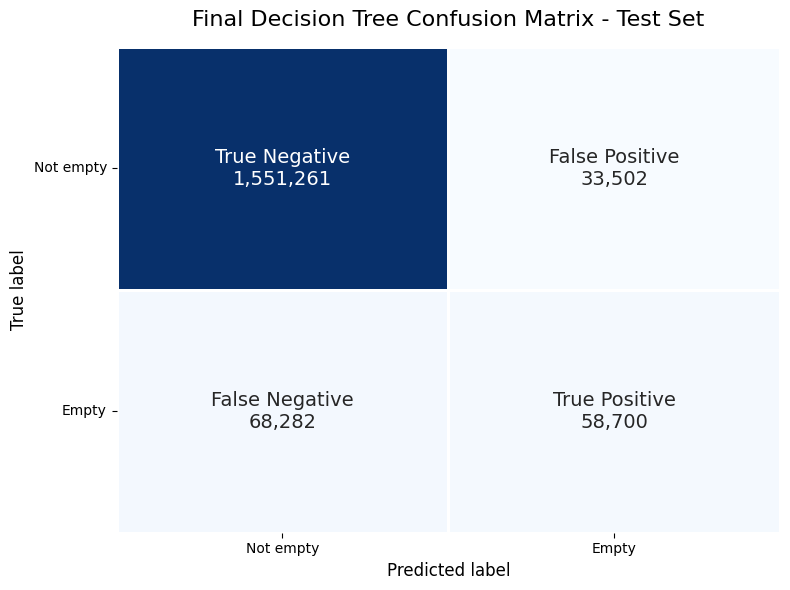

In [41]:
test_cm = confusion_matrix(y_test, final_test_predictions)

labels = np.array([
    [f"True Negative\n{test_cm[0, 0]:,}",
     f"False Positive\n{test_cm[0, 1]:,}"],
    [f"False Negative\n{test_cm[1, 0]:,}",
     f"True Positive\n{test_cm[1, 1]:,}"]
])

plt.figure(figsize=(8, 6))

sns.heatmap(
    test_cm,
    annot=labels,
    fmt='',
    cmap='Blues',
    cbar=False,
    linewidths=2,
    linecolor='white',
    annot_kws={'size': 14}
)

plt.title(
    'Final Decision Tree Confusion Matrix - Test Set',
    fontsize=16,
    pad=15
)

plt.xlabel('Predicted label', fontsize=12)
plt.ylabel('True label', fontsize=12)

plt.xticks([0.5, 1.5], ['Not empty', 'Empty'])
plt.yticks([0.5, 1.5], ['Not empty', 'Empty'], rotation=0)

plt.tight_layout()
plt.show()

## Just for Report Not for Project

Stations On Map

In [31]:
test_map_df = test_df[
    ['id', 'updateTime', 'latitude', 'longitude', 'bikes', 'target']
].copy()

test_map_df['prediction'] = final_test_predictions

prediction_by_time = (
    test_map_df
    .groupby('updateTime')['prediction']
    .sum()
    .sort_values(ascending=False)
)

selected_time = prediction_by_time.index[0]

map_df = test_map_df[
    test_map_df['updateTime'] == selected_time
].copy()

m = folium.Map(
    location=[
        map_df['latitude'].mean(),
        map_df['longitude'].mean()
    ],
    zoom_start=12
)

for _, row in map_df.iterrows():

    color = 'red' if row['prediction'] == 1 else 'blue'

    popup_text = (
        f"Station: {row['id']}<br>"
        f"Bikes now: {row['bikes']}<br>"
        f"Prediction: {'Empty within 60 min' if row['prediction'] == 1 else 'Not empty within 60 min'}<br>"
        f"Actual target: {row['target']}"
    )

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.8,
        popup=popup_text
    ).add_to(m)

m.save("bicing_map.html")

Daily number of Observations and Unique Stations

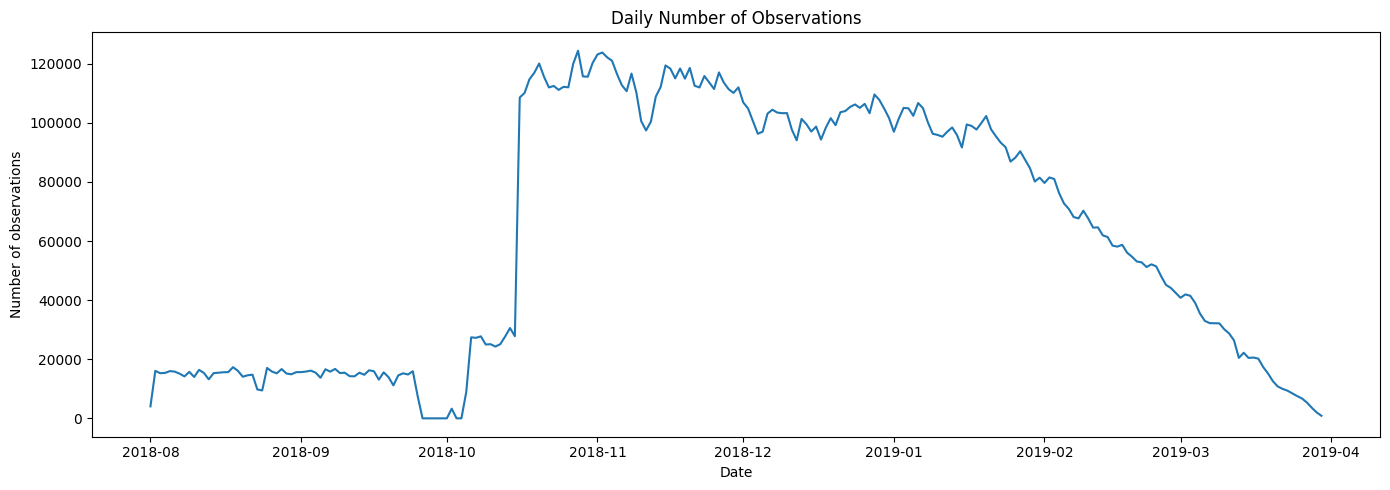

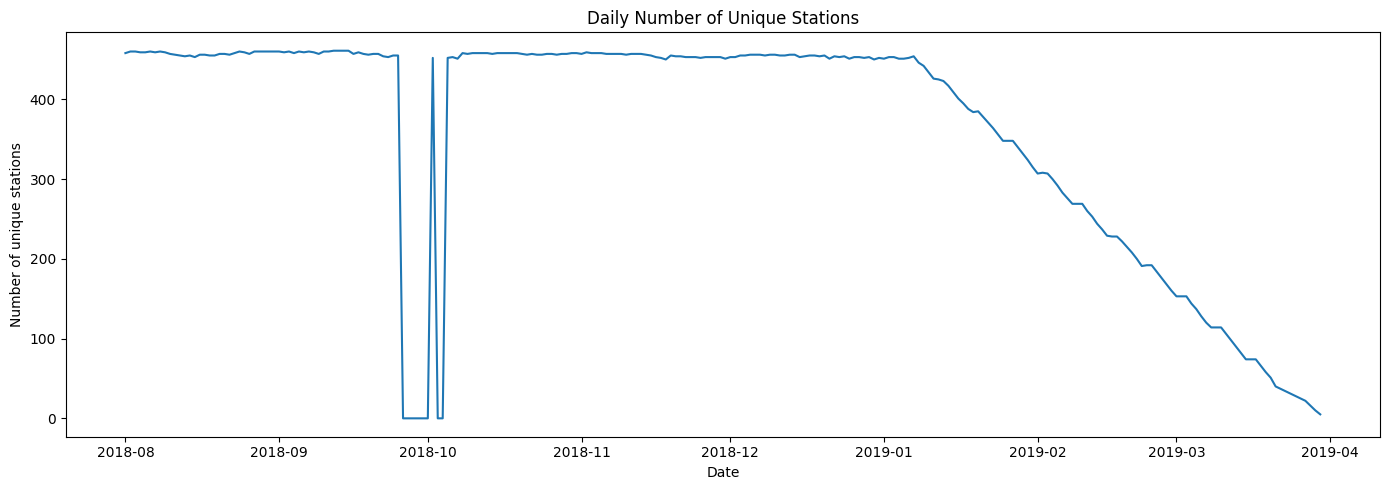

In [32]:
daily_coverage = (
    prediction_df
    .set_index('updateTime')
    .resample('D')
    .agg(
        observations=('id', 'size'),
        unique_stations=('id', 'nunique')
    )
)

plt.figure(figsize=(14, 5))
plt.plot(
    daily_coverage.index,
    daily_coverage['observations']
)
plt.title('Daily Number of Observations')
plt.xlabel('Date')
plt.ylabel('Number of observations')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(
    daily_coverage.index,
    daily_coverage['unique_stations']
)
plt.title('Daily Number of Unique Stations')
plt.xlabel('Date')
plt.ylabel('Number of unique stations')
plt.tight_layout()
plt.show()

Month Approximate positive target rate S

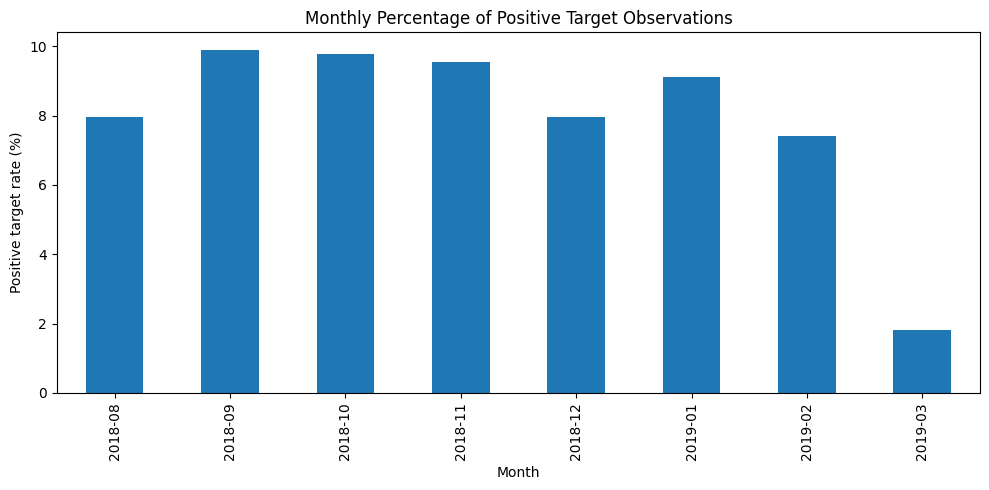

In [33]:
monthly_target = (
    prediction_df
    .assign(month=prediction_df['updateTime'].dt.to_period('M'))
    .groupby('month')['target']
    .mean()
    .mul(100)
)

monthly_target.plot(
    kind='bar',
    figsize=(10, 5),
    title='Monthly Percentage of Positive Target Observations'
)

plt.xlabel('Month')
plt.ylabel('Positive target rate (%)')
plt.tight_layout()
plt.show()

Comparing models

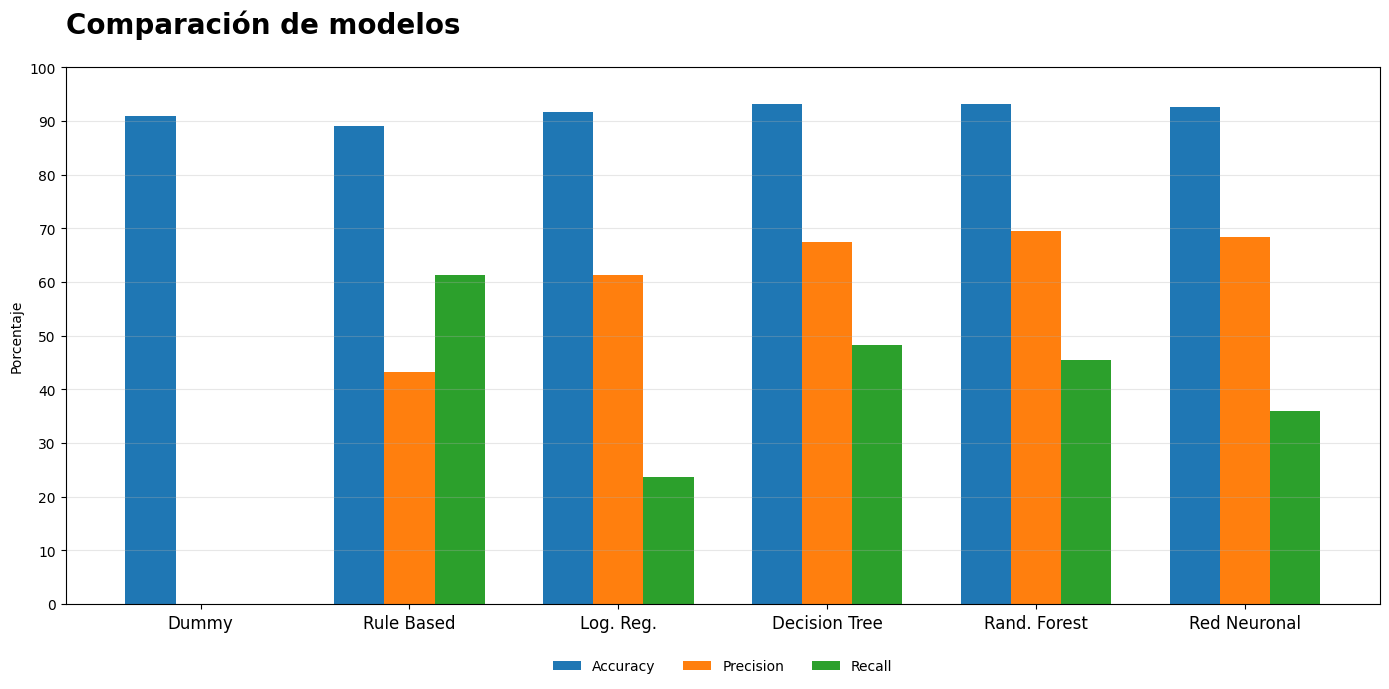

In [42]:
plot_results = results.copy()

plot_results[['Accuracy', 'Precision', 'Recall']] *= 100

plot_results['Model'] = [
    'Dummy',
    'Rule Based',
    'Log. Reg.',
    'Decision Tree',
    'Rand. Forest',
    'Red Neuronal'
]

x = np.arange(len(plot_results))
width = 0.24

plt.figure(figsize=(14, 7))

plt.bar(
    x - width,
    plot_results['Accuracy'],
    width,
    label='Accuracy'
)

plt.bar(
    x,
    plot_results['Precision'],
    width,
    label='Precision'
)

plt.bar(
    x + width,
    plot_results['Recall'],
    width,
    label='Recall'
)

plt.title(
    'Comparación de modelos',
    fontsize=20,
    fontweight='bold',
    loc='left',
    pad=25
)

plt.ylabel('Porcentaje')
plt.xticks(x, plot_results['Model'], fontsize=12)
plt.yticks(np.arange(0, 101, 10))
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.show()

Error Analysis

In [35]:
test_results = X_test.copy()

test_results['target'] = y_test.to_numpy()
test_results['prediction'] = final_test_predictions

false_positives = test_results[
    (test_results['target'] == 0) &
    (test_results['prediction'] == 1)
]

false_negatives = test_results[
    (test_results['target'] == 1) &
    (test_results['prediction'] == 0)
]

error_features = [
    'bikes',
    'occupancy_ratio',
    'bike_change_15m',
    'bike_change_30m'
]

error_summary = pd.DataFrame({
    'False Positive': false_positives[error_features].mean(),
    'False Negative': false_negatives[error_features].mean()
})

error_summary.round(2)

,False Positive,False Negative
bikes,1.95,4.45
occupancy_ratio,0.08,0.19
bike_change_15m,-0.49,-0.25
bike_change_30m,-1.04,-0.45
